In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, matthews_corrcoef
from sklearn.model_selection import GroupKFold
from tqdm import tqdm
import gc

feature_dir = r'D:\M143020071\MI\xgboost_results\ECG_Founder_feature\sr500_0.5_50_MI_win10s_step2s_2-7m_ECG_signal/'
save_path = feature_dir 
if not os.path.exists(save_path): os.makedirs(save_path)

In [2]:
def get_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denom = tp + tn + fp + fn
    acc = (tp + tn) / denom if denom > 0 else 0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    mcc = matthews_corrcoef(y_true, y_pred)
    return [acc, sens, spec, mcc]

def evaluate_predictions(y_true, y_prob, groups, threshold=0.5):
    win_metrics = get_metrics(y_true, (y_prob >= threshold).astype(int))
    df = pd.DataFrame({'ID': groups, 'Actual': y_true, 'Prob': y_prob}).groupby('ID').mean()
    sub_metrics = get_metrics(df['Actual'], (df['Prob'] >= threshold).astype(int))
    return win_metrics, sub_metrics, df

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-MI(0)', 'MI(1)'], 
                yticklabels=['Non-MI(0)', 'MI(1)'], ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

def save_cm_to_csv(y_true, y_pred, filename):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, 
                         index=['Actual_0', 'Actual_1'], 
                         columns=['Predicted_0', 'Predicted_1'])
    full_path = os.path.join(save_path, f"{filename}.csv")
    cm_df.to_csv(full_path)
    print(f"Saved Confusion Matrix: {full_path}")


def process_large_data_in_chunks(file_path, chunk_size=100000):
    """
    使用 Memory Mapping 讀取資料，並分批轉換型別以節省記憶體
    """
    print(f"Opening {os.path.basename(file_path)} with Memory Mapping...")
    # 使用 mmap_mode='r' 讀取，這不會占用 RAM
    data_mmap = np.load(file_path, allow_pickle=True, mmap_mode='r')
    
    total_rows = data_mmap.shape[0]
    num_features = data_mmap.shape[1] - 2
    
    # 預先配置記憶體 (使用 float32 節省一半記憶體)
    X = np.empty((total_rows, num_features), dtype=np.float32)
    y = np.empty(total_rows, dtype=np.int8)
    groups = np.empty(total_rows, dtype=object)
    
    # 分批處理型別轉換，避免產生巨大的中間陣列
    for i in tqdm(range(0, total_rows, chunk_size), desc="Loading Data Chunks"):
        end = min(i + chunk_size, total_rows)
        chunk = data_mmap[i:end]
        
        groups[i:end] = chunk[:, 0]
        y[i:end] = chunk[:, 1].astype(np.float32).astype(np.int8)
        X[i:end] = chunk[:, 2:].astype(np.float32)
        
    del data_mmap
    gc.collect()
    return X, y, groups    

In [3]:
hyper_params_dict = {
    'objective': 'binary:logistic',
    'booster': 'gbtree', 
    'eval_metric': 'aucpr', 
    'learning_rate': 0.05, 
    'n_estimators': 500, 
    'max_depth': 3, 
    'min_child_weight': 1,
    'gamma': 0.1, 
    'subsample': 0.8, 
    'colsample_bytree': 0.8, 
    'reg_alpha': 0.01, 
    'reg_lambda': 1, 
    'random_state': 42
}
batch1 = [ 739, 509, 562, 453, 893, 620, 797, 686, 582, 696, 436, 874, 682, 763, 681, 668, 481, 669, 910, 452, 705, 688, 605, 531, 834, 516, 479, 616, 445, 553, 863, 566, 451, 482, 595, 886, 793, 772, 554, 654, 285, 18, 320, 300, 234, 32, 11, 94, 141, 364, 213, 391, 151, 145, 89, 228, 156, 146, 128, 399, 419, 7, 62, 371, 214, 127, 77, 178, 221, 365, 34, 35, 191, 345, 408, 415, 211, 61, 422, 337]
batch2 = [ 639, 731, 794, 508, 446, 883, 827, 472, 719, 661, 465, 791, 760, 632, 853, 637, 511, 642, 495, 880, 664, 721, 858, 552, 839, 665, 447, 628, 442, 522, 598, 810, 640, 470, 871, 483, 560, 750, 458, 489, 331, 367, 378, 386, 361, 362, 244, 73, 147, 339, 249, 110, 60, 84, 154, 123, 15, 203, 168, 301, 225, 351, 134, 216, 99, 212, 105, 26, 407, 115, 338, 291, 262, 160, 16, 198, 313, 257, 71, 341]
batch3 = [477, 525, 899, 606, 558, 537, 921, 607, 667, 892, 629, 467, 455, 625, 544, 618, 433, 757, 528, 736, 575, 821, 624, 895, 487, 597, 807, 563, 500, 769, 646, 785, 593, 486, 541, 657, 684, 748, 427, 627, 92, 305, 349, 140, 288, 410, 304, 294, 325, 416, 201, 342, 421, 130, 274, 219, 396, 3, 412, 348, 114, 380, 269, 14, 20, 64, 329, 414, 12, 119, 268, 397, 233, 333, 295, 48, 38, 157, 144, 24]
batch4 = [468, 867, 475, 842, 626, 506, 494, 592, 725, 818, 697, 587, 702, 559, 768, 701, 835, 496, 444, 538, 706, 901, 650, 903, 459, 809, 816, 838, 909, 776, 425, 671, 820, 520, 751, 448, 600, 574, 891, 879, 384, 239, 406, 51, 193, 149, 22, 74, 366, 417, 238, 403, 65, 124, 280, 167, 409, 265, 240, 103, 183, 155, 220, 36, 424, 200, 394, 78, 375, 49, 299, 169, 55, 308, 87, 344, 58, 354, 72, 368]
batch5 = [802, 673, 656, 900, 529, 532, 638, 762, 584, 823, 556, 499, 723, 543, 710, 473, 610, 692, 830, 464, 512, 885, 801, 894, 432, 655, 515, 740, 683, 633, 463, 449, 510, 608, 578, 614, 611, 711, 588, 866, 104, 328, 209, 271, 86, 336, 235, 290, 197, 152, 404, 210, 112, 29, 251, 108, 82, 113, 159, 13, 237, 21, 256, 358, 302, 383, 264, 303, 270, 10, 369, 243, 346, 312, 135, 226, 2, 47, 332, 372]

all_batches = [batch1, batch2, batch3, batch4, batch5]


Processing Feature: ECG_Founder_features.npy
Opening ECG_Founder_features.npy with Memory Mapping...


Loading Data Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Cross Validation Folds: 100%|██████████| 5/5 [00:18<00:00,  3.65s/it]


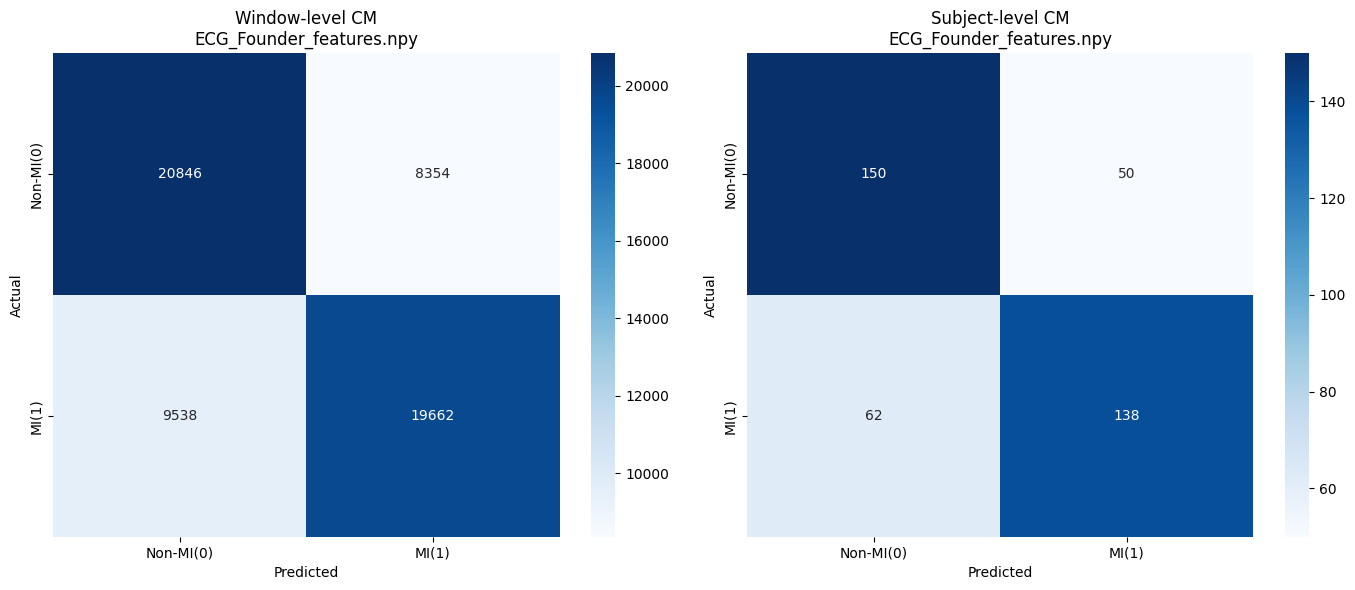

Saved Confusion Matrix: D:\M143020071\MI\xgboost_results\ECG_Founder_feature\sr500_0.5_50_MI_win10s_step2s_2-7m_ECG_signal/ECG_Founder_features_win_cm.csv
Saved Confusion Matrix: D:\M143020071\MI\xgboost_results\ECG_Founder_feature\sr500_0.5_50_MI_win10s_step2s_2-7m_ECG_signal/ECG_Founder_features_sub_cm.csv

Processing Feature: ECG_Founder_deep_features.npy
Opening ECG_Founder_deep_features.npy with Memory Mapping...


Cross Validation Folds: 100%|██████████| 5/5 [04:55<00:00, 59.13s/it]


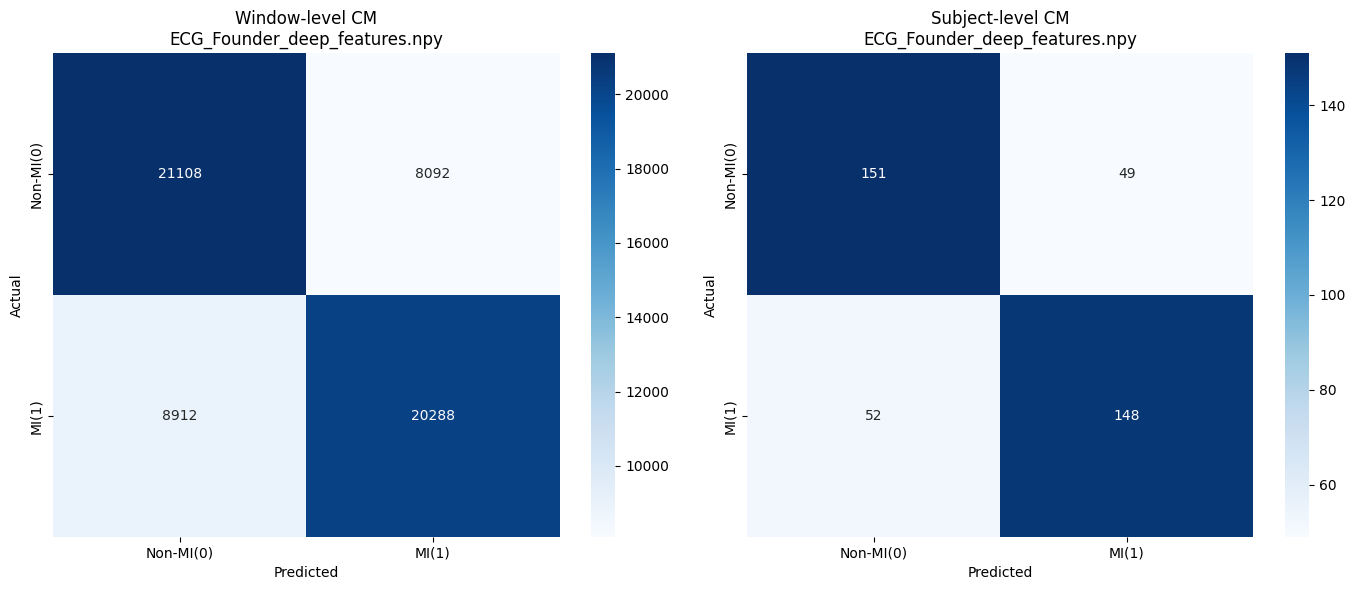

Saved Confusion Matrix: D:\M143020071\MI\xgboost_results\ECG_Founder_feature\sr500_0.5_50_MI_win10s_step2s_2-7m_ECG_signal/ECG_Founder_deep_features_win_cm.csv
Saved Confusion Matrix: D:\M143020071\MI\xgboost_results\ECG_Founder_feature\sr500_0.5_50_MI_win10s_step2s_2-7m_ECG_signal/ECG_Founder_deep_features_sub_cm.csv

Processing Complete!
                      Model_Type  Accuracy  Sensitivity  Specificity       MCC
0       ECG_Founder_features_Win  0.693630     0.673356     0.713904  0.387579
1       ECG_Founder_features_Sub  0.720000     0.690000     0.750000  0.440794
2  ECG_Founder_deep_features_Win  0.708836     0.694795     0.722877  0.417836
3  ECG_Founder_deep_features_Sub  0.747500     0.740000     0.755000  0.495056


In [5]:
feature_files = ['ECG_Founder_features.npy', 'ECG_Founder_deep_features.npy']
all_final_metrics = []

for f_file in feature_files:
    print(f"\n{'='*40}\nProcessing Feature: {f_file}\n{'='*40}")
    
    file_path = os.path.join(feature_dir, f_file)
    
    try:
        X, y, groups = process_large_data_in_chunks(file_path)
    except Exception as e:
        print(f"Error loading {f_file}: {e}")
        continue
    
    
    all_y_true = []
    all_y_probs = []
    all_groups = []
    
    gkf = GroupKFold(n_splits=5)
    splits = list(gkf.split(X, y, groups))
   
    for fold,test_batch in enumerate(tqdm(all_batches, desc="Cross Validation Folds")):
        test_group_names = [f"{i:04d}" for i in test_batch]
        is_test = np.isin(groups, test_group_names)
        test_idx = np.where(is_test)[0]
        train_idx = np.where(~is_test)[0]
        
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        groups_test = groups[test_idx]
        
        model = XGBClassifier(**hyper_params_dict)
        model.fit(X_train, y_train)
        
        test_prob = model.predict_proba(X_test)[:, 1]
        
        all_y_true.append(y_test)
        all_y_probs.append(test_prob)
        all_groups.append(groups_test)
       
        del X_train, X_test, y_train, y_test, model
        gc.collect()

    y_true_combined = np.concatenate(all_y_true)
    y_probs_combined = np.concatenate(all_y_probs)
    groups_combined = np.concatenate(all_groups)

    win_metrics, sub_metrics, df_sub = evaluate_predictions(y_true_combined, y_probs_combined, groups_combined)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plot_confusion_matrix(y_true_combined, (y_probs_combined >= 0.5).astype(int), 
                          f"Window-level CM\n{f_file}", axes[0])
    plot_confusion_matrix(df_sub['Actual'], (df_sub['Prob'] >= 0.5).astype(int), 
                          f"Subject-level CM\n{f_file}", axes[1])
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f"{f_file.split('.')[0]}_Stacked_CM.png"))
    plt.show()

    save_cm_to_csv(y_true_combined, (y_probs_combined >= 0.5).astype(int), f"{f_file.split('.')[0]}_win_cm")
    save_cm_to_csv(df_sub['Actual'], (df_sub['Prob'] >= 0.5).astype(int), f"{f_file.split('.')[0]}_sub_cm")

    res_prefix = f_file.split('.')[0]
    all_final_metrics.append([res_prefix + "_Win"] + win_metrics)
    all_final_metrics.append([res_prefix + "_Sub"] + sub_metrics)

    del X, y, groups, df_sub, y_true_combined, y_probs_combined
    gc.collect() 

cols = ['Model_Type', 'Accuracy', 'Sensitivity', 'Specificity', 'MCC']
summary_df = pd.DataFrame(all_final_metrics, columns=cols)
summary_df.to_csv(os.path.join(save_path, "XGBoost_Final_ALL_Metrics.csv"), index=False)

print("\nProcessing Complete!")
print(summary_df)